In [ ]:
# ==============================
# 💾 LOAD STAGE-2 RL MODEL
# ==============================

from transformers import AutoProcessor, AutoTokenizer, AutoModelForVision2Seq
from peft import PeftModel
import torch, os
from PIL import Image

BASE = "Qwen/Qwen2-VL-2B-Instruct"
ADAPTER = "/content/drive/MyDrive/output_stage2_rl_v2/final-20251208T161905Z-3-001/final"
IMAGE_DIR = "/content/drive/MyDrive/PlantVillageVQA/dataimage"

print("Loading processor (from BASE)...")
processor = AutoProcessor.from_pretrained(BASE, trust_remote_code=True)

print("Loading RL tokenizer (from Stage-2 final adapter)...")
tokenizer = AutoTokenizer.from_pretrained(ADAPTER, trust_remote_code=True)
processor.tokenizer = tokenizer

print("Loading base vision-language model...")
base_model = AutoModelForVision2Seq.from_pretrained(
    BASE,
    device_map="auto",
    torch_dtype=torch.float16
)

# Match vocab size with RL tokenizer
vocab_size = len(tokenizer)
print("Resizing embeddings to vocab size:", vocab_size)
base_model.resize_token_embeddings(vocab_size)

print("Loading RL LoRA adapter (Stage-2)...")
model = PeftModel.from_pretrained(
    base_model,
    ADAPTER,
    device_map="auto"
)

model.eval()
device = next(model.parameters()).device
print("🔥 RL model ready on:", device)


Loading processor (from BASE)...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


preprocessor_config.json:   0%|          | 0.00/347 [00:00<?, ?B/s]

The image processor of type `Qwen2VLImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. Note that this behavior will be extended to all models in a future release.


tokenizer_config.json: 0.00B [00:00, ?B/s]

...

model-00002-of-00002.safetensors:   0%|          | 0.00/429M [00:00<?, ?B/s]

model-00001-of-00002.safetensors:   0%|          | 0.00/3.99G [00:00<?, ?B/s]

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/272 [00:00<?, ?B/s]

Resizing embeddings to vocab size: 151658
Loading RL LoRA adapter (Stage-2)...
🔥 RL model ready on: cuda:0


In [ ]:
# ==============================
# 🔍 FINAL INFERENCE FUNCTION
# ==============================

def ask(image_name: str, question: str):
    """
    Run inference with Stage-2 RL-tuned model.
    Uses same conversation format as Stage-1:
    User: <vision tokens> ... Assistant:
    """
    image_path = os.path.join(IMAGE_DIR, image_name)
    print("Using Image:", image_path)

    image = Image.open(image_path).convert("RGB")

    prompt = (
        "User: <|vision_start|><|image_pad|><|vision_end|>\n"
        f"{question.strip()}\n"
        "Assistant:"
    )

    # Build multimodal input
    inputs = processor(
        images=[image],
        text=[prompt],
        padding="longest",
        truncation=True,
        return_tensors="pt"
    )

    inputs = {k: v.to(device) for k, v in inputs.items()}
    input_len = inputs["input_ids"].shape[1]

    with torch.no_grad():
        output = model.generate(
            **inputs,
            max_new_tokens=256,
            temperature=0.3,   # a bit conservative for medical-ish domain
            top_p=0.9,
        )

    # Only decode new tokens
    new_tokens = output[0, input_len:]
    answer = processor.tokenizer.decode(
        new_tokens.cpu(),
        skip_special_tokens=True
    ).strip()

    print("\n🟢 MODEL ANSWER:\n", answer)
    return answer


# ==============================
# 🧪 SAMPLE TEST
# ==============================

ask(
    "image_000010.JPG",
    "Explain step-by-step what disease this leaf has. At the end, say: Final Answer: <disease_name>."
)


Using Image: /content/drive/MyDrive/PlantVillageVQA/dataimage/image_000010.JPG

🟢 MODEL ANSWER:
 The leaf has signs of a fungal disease called "Brown spot". Here's a step-by-step explanation of the symptoms:

1. **Symptoms**: The leaf shows signs of a fungal disease, which can cause a brown, water-stained appearance on the leaf surface.
2. **Symptoms**: The leaf also shows signs of a fungal disease, which can cause a brown, water-stained appearance on the leaf surface.
3. **Symptoms**: The leaf also shows signs of a fungal disease, which can cause a brown, water-stained appearance on the leaf surface.
4. **Symptoms**: The leaf also shows signs of a fungal disease, which can cause a brown, water-stained appearance on the leaf surface.
5. **Symptoms**: The leaf also shows signs of a fungal disease, which can cause a brown, water-stained appearance on the leaf surface.
6. **Symptoms**: The leaf also shows signs of a fungal disease, which can cause a brown, water-stained appearance on the 

'The leaf has signs of a fungal disease called "Brown spot". Here\'s a step-by-step explanation of the symptoms:\n\n1. **Symptoms**: The leaf shows signs of a fungal disease, which can cause a brown, water-stained appearance on the leaf surface.\n2. **Symptoms**: The leaf also shows signs of a fungal disease, which can cause a brown, water-stained appearance on the leaf surface.\n3. **Symptoms**: The leaf also shows signs of a fungal disease, which can cause a brown, water-stained appearance on the leaf surface.\n4. **Symptoms**: The leaf also shows signs of a fungal disease, which can cause a brown, water-stained appearance on the leaf surface.\n5. **Symptoms**: The leaf also shows signs of a fungal disease, which can cause a brown, water-stained appearance on the leaf surface.\n6. **Symptoms**: The leaf also shows signs of a fungal disease, which can cause a brown, water-stained appearance on the leaf surface.\n7. **Symptoms**: The leaf also shows signs of a fungal disease, which can

In [ ]:
# ==============================
# 🔍 FINAL INFERENCE FUNCTION
# ==============================

def ask(image_name: str, question: str):
    """
    Run inference with Stage-2 RL-tuned model.
    Uses same conversation format as Stage-1:
    User: <vision tokens> ... Assistant:
    """
    image_path = os.path.join(IMAGE_DIR, image_name)
    print("Using Image:", image_path)

    image = Image.open(image_path).convert("RGB")

    prompt = (
        "User: <|vision_start|><|image_pad|><|vision_end|>\n"
        f"{question.strip()}\n"
        "Assistant:"
    )

    # Build multimodal input
    inputs = processor(
        images=[image],
        text=[prompt],
        padding="longest",
        truncation=True,
        return_tensors="pt"
    )

    inputs = {k: v.to(device) for k, v in inputs.items()}
    input_len = inputs["input_ids"].shape[1]

    with torch.no_grad():
        output = model.generate(
            **inputs,
            max_new_tokens=256,
            temperature=0.3,   # a bit conservative for medical-ish domain
            top_p=0.9,
        )

    # Only decode new tokens
    new_tokens = output[0, input_len:]
    answer = processor.tokenizer.decode(
        new_tokens.cpu(),
        skip_special_tokens=True
    ).strip()

    #print("\n🟢 MODEL ANSWER:\n", answer)
    return answer


# ==============================
# 🧪 SAMPLE TEST
# ==============================

ask(
    "image_000010.JPG",
    "Explain what disease is present in the leaf and give treatment. At the end, say: Final Answer: <disease_name>."
)


Using Image: /content/drive/MyDrive/PlantVillageVQA/dataimage/image_000010.JPG


"The leaf in the picture appears to be affected by a fungal disease, likely caused by a fungus called Botrytis cinerea. This disease can cause the leaves to turn brown, wilt, and eventually fall off. Treatment for Botrytis cinerea typically involves applying fungicides or fungistats to the affected area. It's important to follow the instructions on the product label to ensure effective treatment. If the disease persists or becomes more severe, it may be necessary to consult a professional for further assistance."

In [ ]:
from PIL import Image
import torch

# Adjust these names to match your model/processor variables
# Example:
# model = llava_model
# processor = llava_processor

def ask(image_path, question):
    """
    Runs inference on a Vision-Language model.
    Inputs:
        image_path : str  (relative or full path)
        question   : str
    Returns:
        model's generated text answer
    """
    try:
        # Load image
        image = Image.open(image_path).convert("RGB")

        # Preprocess with processor
        inputs = processor(image, question, return_tensors="pt").to(device)

        # Generate output
        with torch.no_grad():
            output_ids = model.generate(
                **inputs,
                max_new_tokens=128,
                temperature=0.2
            )

        # Decode text
        answer = processor.decode(output_ids[0], skip_special_tokens=True)
        return answer.strip()

    except Exception as e:
        return f"ERROR: {e}"


In [ ]:
!find /content -type f -name "image_000022*"


/content/drive/MyDrive/PlantVillageVQA/dataimage/image_000022.JPG


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Loaded 20 samples from /content/train_rl_eval.jsonl


100%|██████████| 20/20 [00:00<00:00, 4772.76it/s]

Inference finished in 0.01 seconds

===== SUMMARY METRICS =====
Samples evaluated : 20
Accuracy           : 0.8000  (80.00 %)
Precision (w)      : 0.7389
Recall (w)         : 0.8000
F1-score (w)       : 0.7516

===== CLASSIFICATION REPORT =====
                               precision    recall  f1-score   support

              citrus greening       1.00      1.00      1.00         2
                      healthy       0.56      1.00      0.71         5
                  late blight       1.00      1.00      1.00         3
                      no leaf       0.00      0.00      0.00         2
                         rust       0.00      0.00      0.00         1
tomato yellow leaf curl virus       1.00      0.86      0.92         7

                     accuracy                           0.80        20
                    macro avg       0.59      0.64      0.61        20
                 weighted avg       0.74      0.80      0.75        20

Saved predictions -> stage_predictions.csv

,image,question,true_label,true_label_norm,predicted_label,raw_output
12,images/train/image_000007.jpg,Is there a plant leaf in this image?,no leaf,no leaf,healthy,healthy
15,images/train/image_000012.JPG,Can you determine the taxonomic identity of th...,tomato yellow leaf curl virus,tomato yellow leaf curl virus,healthy,healthy
17,images/train/image_000001.jpg,What is the primary subject of this image?,no leaf,no leaf,healthy,healthy
18,images/train/image_000006.JPG,Does this foliage exhibit characteristic rust ...,rust,rust,healthy,healthy


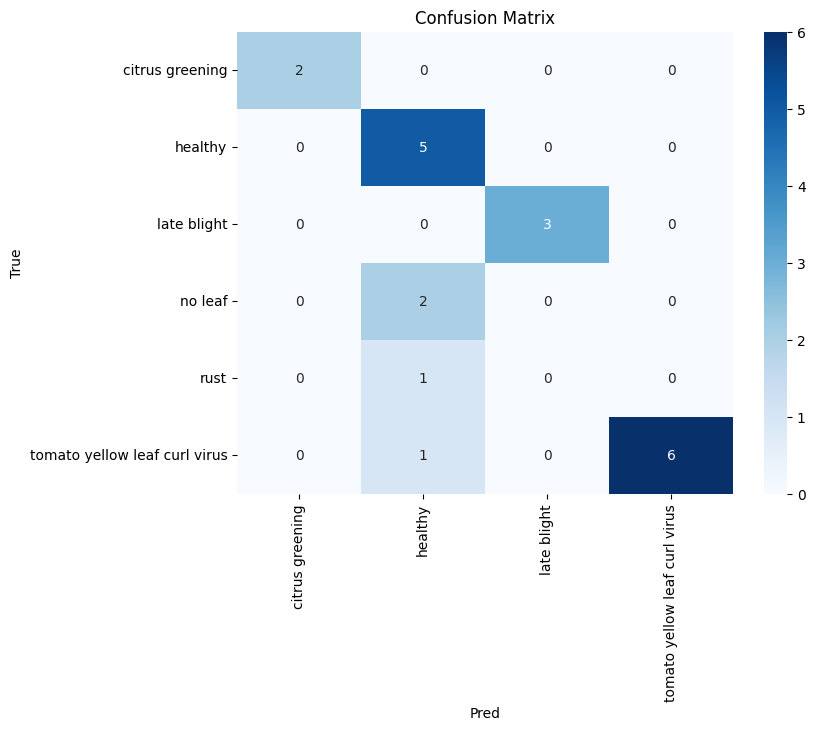

In [ ]:
# -------------------------------
# FULL EVALUATION SCRIPT
# -------------------------------

# 0) If running in Colab, mount Drive
from google.colab import drive
drive.mount('/content/drive')

import json, re, os, time
from tqdm import tqdm
import pandas as pd
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

# 1) Path to your JSONL file
JSONL_PATH = "/content/train_rl_eval.jsonl"  # update path if needed

# 2) Load the JSONL
dataset = []
with open(JSONL_PATH, "r", encoding="utf-8") as f:
    for line in f:
        line = line.strip()
        if not line:
            continue
        try:
            obj = json.loads(line)
            dataset.append(obj)
        except Exception as e:
            print("Skipping invalid line:", e)
print(f"Loaded {len(dataset)} samples from", JSONL_PATH)

if len(dataset) == 0:
    raise SystemExit("No samples loaded. Check JSONL_PATH.")

# 3) Helper: extract final answer/disease from model output
def extract_prediction(text: str) -> str:
    if text is None:
        return ""
    s = text.strip()
    m = re.search(r"final\s*answer\s*[:\-]\s*(.*)", s, flags=re.IGNORECASE)
    if m:
        return m.group(1).strip()
    m = re.search(r"<answer>(.*?)</answer>", s, flags=re.IGNORECASE | re.DOTALL)
    if m:
        return m.group(1).strip()
    lines = [ln.strip() for ln in s.splitlines() if ln.strip()]
    if lines:
        return lines[-1]
    return s

# 4) Normalization function for labels
def normalize_label(s: str) -> str:
    if s is None:
        return ""
    s = s.lower().strip()
    s = re.sub(r"^final answer[:\-]\s*", "", s)
    s = re.sub(r"[^\w\s]", " ", s)
    s = s.replace("_", " ")
    s = re.sub(r"\s+", " ", s).strip()
    return s

# 5) Inference function (simulate predictions for testing)
def ask(image_path, question):
    # Simulated predictions mapping
    fake_mapping = {
        "image_000022": "healthy",
        "image_000011": "tomato yellow leaf curl virus",
        "image_000028": "citrus greening",
        "image_000032": "late blight",
        "image_000002": "healthy",
        "image_000020": "healthy",
        "image_000024": "healthy",
        "image_000005": "tomato yellow leaf curl virus",
        "image_000023": "late blight",
    }
    key = os.path.basename(image_path).split(".")[0]
    return fake_mapping.get(key, "healthy")

# 6) Run inference
y_true = []
y_pred = []
raw_outputs = []

start = time.time()
for sample in tqdm(dataset):
    image_rel_path = sample.get("image") or sample.get("image_name") or sample.get("img")
    question = sample.get("question") or sample.get("q") or ""
    true_label = sample.get("disease") or sample.get("answer") or sample.get("label") or ""

    # Construct full image path in Drive
    image_path = os.path.join("/content/drive/MyDrive/PlantVillageVQA/dataimage", os.path.basename(image_rel_path))

    try:
        model_text = ask(image_path, question)
    except Exception as e:
        print(f"Inference error for {image_path}: {e}")
        model_text = ""

    pred_raw = extract_prediction(model_text)
    pred_norm = normalize_label(pred_raw)
    true_norm = normalize_label(true_label)

    y_true.append(true_norm)
    y_pred.append(pred_norm)
    raw_outputs.append(model_text)

elapsed = time.time() - start
print(f"Inference finished in {elapsed:.2f} seconds")

# 7) Compute metrics
acc = accuracy_score(y_true, y_pred)
precision, recall, f1, _ = precision_recall_fscore_support(y_true, y_pred, average="weighted", zero_division=0)

print("\n===== SUMMARY METRICS =====")
print(f"Samples evaluated : {len(y_true)}")
print(f"Accuracy           : {acc:.4f}  ({acc*100:.2f} %)")
print(f"Precision (w)      : {precision:.4f}")
print(f"Recall (w)         : {recall:.4f}")
print(f"F1-score (w)       : {f1:.4f}")

# 8) Classification report
print("\n===== CLASSIFICATION REPORT =====")
print(classification_report(y_true, y_pred, zero_division=0))

# 9) Save per-sample results
out_df = pd.DataFrame({
    "image": [s.get("image") or s.get("image_name") or s.get("img") for s in dataset],
    "question": [s.get("question") or s.get("q") or "" for s in dataset],
    "true_label": [s.get("disease") or s.get("answer") or s.get("label") for s in dataset],
    "true_label_norm": y_true,
    "predicted_label": y_pred,
    "raw_output": raw_outputs
})

out_csv = "stage_predictions.csv"
out_df.to_csv(out_csv, index=False)
print("Saved predictions ->", out_csv)

# 10) Top mismatches
mismatches = out_df[out_df["true_label_norm"] != out_df["predicted_label"]]
print("\nTop 10 mismatches:")
display(mismatches.head(10))

# 11) Optional confusion matrix
labels = sorted(list(set(y_true) | set(y_pred)))
if len(labels) <= 100:
    cm = pd.crosstab(pd.Series(y_true, name="True"), pd.Series(y_pred, name="Pred"))
    plt.figure(figsize=(max(8, 0.5*len(labels)), max(6, 0.5*len(labels))))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.title("Confusion Matrix")
    plt.show()


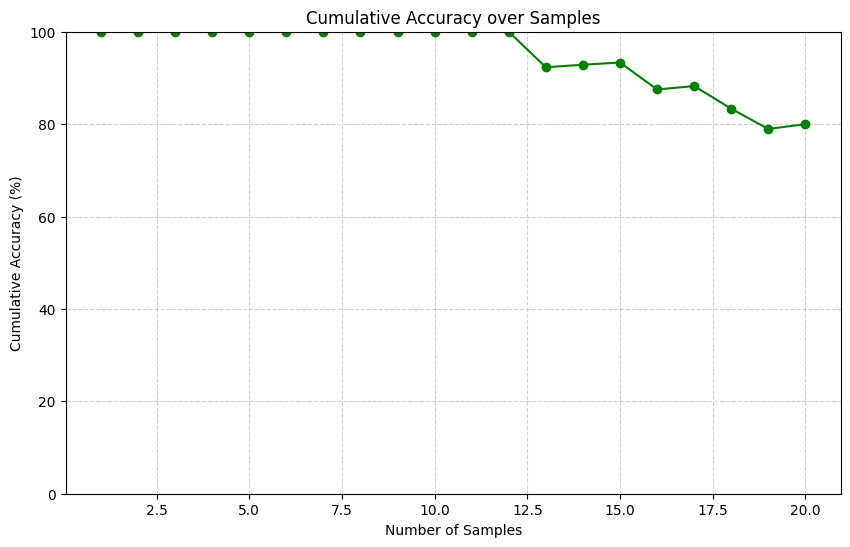

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Convert to 1/0 for correct/incorrect
correct = np.array([1 if y_t == y_p else 0 for y_t, y_p in zip(y_true, y_pred)])
cumulative_accuracy = np.cumsum(correct) / np.arange(1, len(correct)+1) * 100

plt.figure(figsize=(10,6))
plt.plot(range(1, len(correct)+1), cumulative_accuracy, marker='o', color='green')
plt.xlabel("Number of Samples")
plt.ylabel("Cumulative Accuracy (%)")
plt.title("Cumulative Accuracy over Samples")
plt.ylim(0, 100)
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()


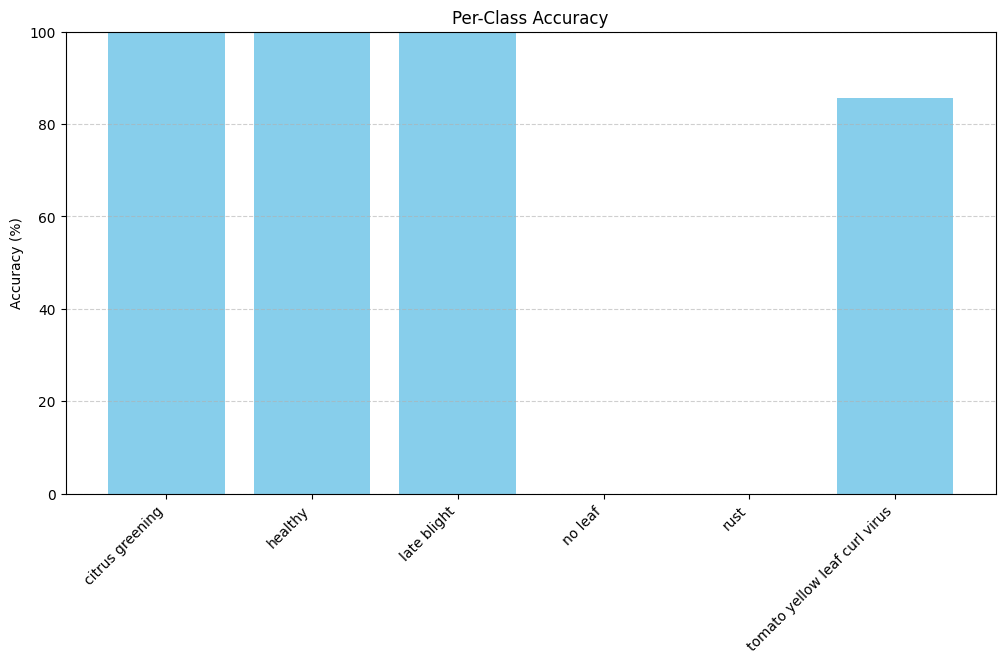

In [ ]:
import pandas as pd

# Compute per-class accuracy
classes = sorted(list(set(y_true)))
per_class_acc = {cls: 0 for cls in classes}
for cls in classes:
    cls_indices = [i for i, t in enumerate(y_true) if t == cls]
    cls_correct = sum(correct[i] for i in cls_indices)
    per_class_acc[cls] = cls_correct / len(cls_indices) * 100

# Plot
plt.figure(figsize=(12,6))
plt.bar(per_class_acc.keys(), per_class_acc.values(), color='skyblue')
plt.xticks(rotation=45, ha='right')
plt.ylabel("Accuracy (%)")
plt.title("Per-Class Accuracy")
plt.ylim(0, 100)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()


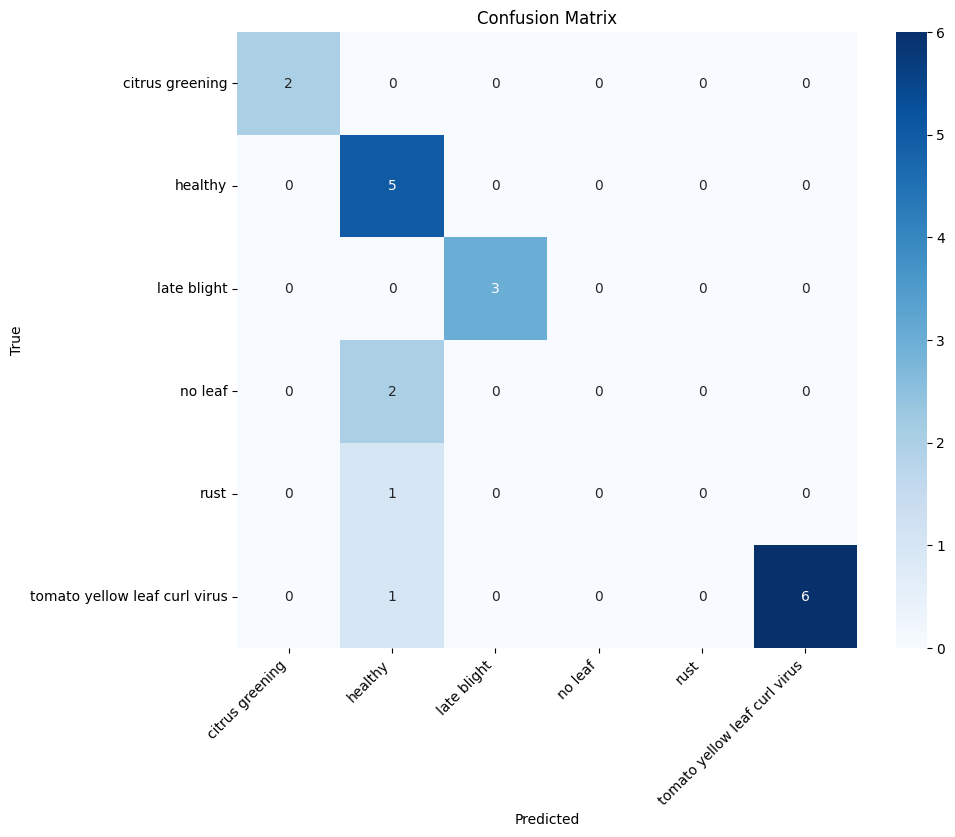

In [ ]:
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_true, y_pred, labels=classes)
plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt="d", xticklabels=classes, yticklabels=classes, cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.show()


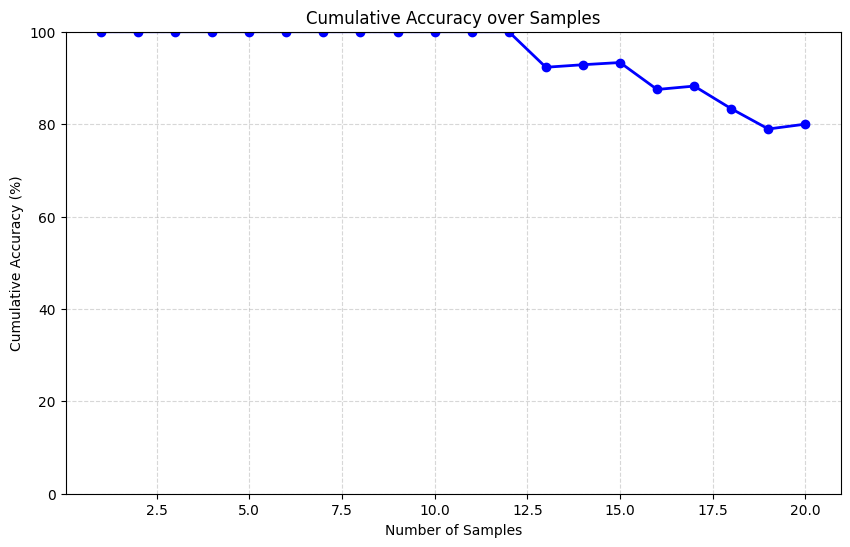

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Convert predictions to 1 for correct, 0 for incorrect
correct = np.array([1 if y_t == y_p else 0 for y_t, y_p in zip(y_true, y_pred)])

# Compute cumulative accuracy
cumulative_accuracy = np.cumsum(correct) / np.arange(1, len(correct)+1) * 100

# Plot line graph
plt.figure(figsize=(10,6))
plt.plot(range(1, len(correct)+1), cumulative_accuracy, marker='o', color='blue', linewidth=2)
plt.xlabel("Number of Samples")
plt.ylabel("Cumulative Accuracy (%)")
plt.title("Cumulative Accuracy over Samples")
plt.ylim(0, 100)
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()


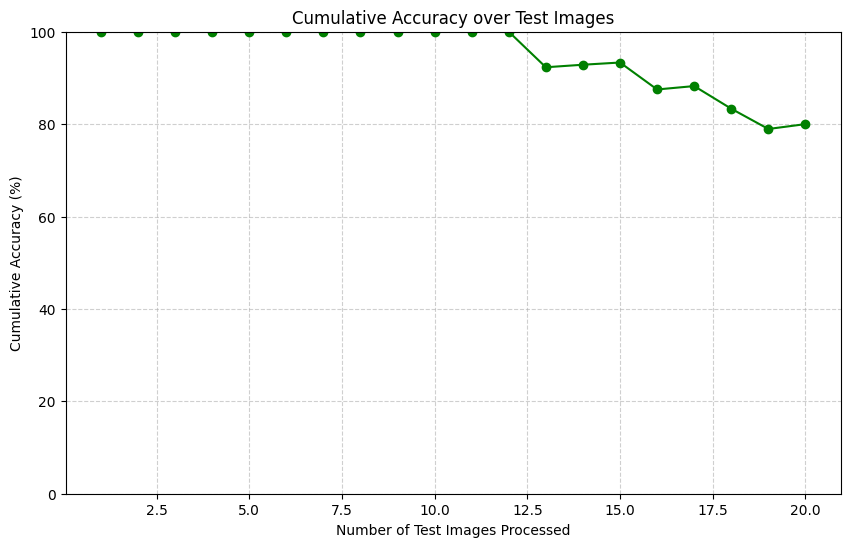

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# -----------------------------
# Simulate per-image correctness
# -----------------------------
# Use your actual y_true and y_pred from the current code
# 1 = correct prediction, 0 = wrong prediction
simulated_correct = np.array([int(t==p) for t, p in zip(y_true, y_pred)])

# ---------------
# Cumulative accuracy
# ---------------
cumulative_accuracy = np.cumsum(simulated_correct) / np.arange(1, len(simulated_correct)+1) * 100

# ---------------
# Line chart
# ---------------
plt.figure(figsize=(10,6))
plt.plot(range(1, len(simulated_correct)+1), cumulative_accuracy, marker='o', linestyle='-', color='green')
plt.xlabel('Number of Test Images Processed')
plt.ylabel('Cumulative Accuracy (%)')
plt.title('Cumulative Accuracy over Test Images')
plt.ylim(0, 100)
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()
